# 生存分析：KM曲线 + Log-rank检验

目标：
1. 理解生存分析三要素：生存时间、事件、删失
2. 用 Kaplan-Meier 方法估计用户生存（留存）函数
3. 分组绘制 KM 曲线，对比不同用户群体的留存差异
4. 用 Log-rank 检验验证差异是否统计显著

**为什么不用普通统计方法？** 
生存分析能处理「删失数据」——即观察期内未发生流失的用户。普通 t 检验/卡方检验会忽略这些信息，导致偏差。

## 0. 环境准备

In [16]:
import sys, os
from pathlib import Path

# ---- 自动定位项目根目录 ----
_cwd = Path(os.getcwd())
if (_cwd / 'scripts').exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / 'scripts').exists():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = Path(r'C:\Users\15854\WorkBuddy\2026-08-08-17-04-03\churn-survival-analysis')

os.chdir(str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / 'scripts'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from db_config import get_sqlalchemy_url

# 生存分析库
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

# 中文字体（必须先 set_style 再设字体，否则 seaborn 会覆盖）
sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False

# 安全保存图片：遇到文件被占用自动换名，不再报错
def safe_savefig(path, **kwargs):
    try:
        plt.savefig(path, **kwargs)
    except PermissionError:
        alt = path.replace('.png', '_new.png')
        plt.savefig(alt, **kwargs)
        print(f'⚠️ 原文件被占用，已保存到: {alt}')

print(f'项目根目录: {PROJECT_ROOT}')
print(f'lifelines 版本: {__import__("lifelines").__version__}')
print('✅ 环境准备完成')

项目根目录: C:\Users\15854\WorkBuddy\2026-08-08-17-04-03\churn-survival-analysis
lifelines 版本: 0.30.3
✅ 环境准备完成


## 1. 读取数据并准备生存分析格式

In [17]:
engine = create_engine(get_sqlalchemy_url())
df = pd.read_sql('SELECT * FROM telco_churn', con=engine)
print(f'数据形状: {df.shape}')
display(df.head())

数据形状: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0002-ORFBO,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,No
1,0003-MKNFE,Male,0,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,No
2,0004-TLHLJ,Male,0,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,Yes
3,0011-IGKFF,Male,1,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,Yes
4,0013-EXCHZ,Female,1,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,Yes


### 1.1 生存分析数据格式

生存分析需要两个核心变量：
- **duration（生存时间）**：`tenure` — 用户在网月数
- **event（事件）**：`Churn` — 1=流失（事件发生），0=未流失（删失）

删失（censored）的含义：用户在观察期内没有流失，但我们不知道之后会不会流失。生存分析能正确利用这部分信息，而普通方法会丢弃它们。

In [18]:
# 转换 Churn 为二进制事件变量
df['event'] = df['Churn'].map({'Yes': 1, 'No': 0})

# tenure=0 的用户（刚注册就流失），生存分析要求 duration > 0
# 处理方式：设为 0.5（半个月），表示不到一个月就流失
df.loc[df['tenure'] == 0, 'tenure'] = 0.5

print(f'tenure 范围: {df["tenure"].min()} - {df["tenure"].max()}')
print(f'事件(流失)数: {df["event"].sum()}')
print(f'删失(未流失)数: {(df["event"] == 0).sum()}')
print(f'流失率: {df["event"].mean() * 100:.2f}%')
print('\n生存数据格式预览:')
display(df[['customerID', 'tenure', 'Churn', 'event']].head(10))

tenure 范围: 0.5 - 72.0
事件(流失)数: 1869
删失(未流失)数: 5174
流失率: 26.54%

生存数据格式预览:


C:\Users\15854\AppData\Local\Temp\ipykernel_11824\1262886167.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['tenure'] == 0, 'tenure'] = 0.5


,customerID,tenure,Churn,event
0,0002-ORFBO,9.0,No,0
1,0003-MKNFE,9.0,No,0
2,0004-TLHLJ,4.0,Yes,1
3,0011-IGKFF,13.0,Yes,1
4,0013-EXCHZ,3.0,Yes,1
5,0013-MHZWF,9.0,No,0
6,0013-SMEOE,71.0,No,0
7,0014-BMAQU,63.0,No,0
8,0015-UOCOJ,7.0,No,0
9,0016-QLJIS,65.0,No,0


## 2. Kaplan-Meier 生存曲线

### 2.1 总体生存曲线

KM 估计法是一种非参数方法，用于估计生存函数 S(t) = P(T > t)，
即用户在 t 时刻仍然留存的概率。

曲线每次在一个流失事件发生时「下降」，删失则用竖线标记。

⚠️ 原文件被占用，已保存到: output/10_km_overall_new.png


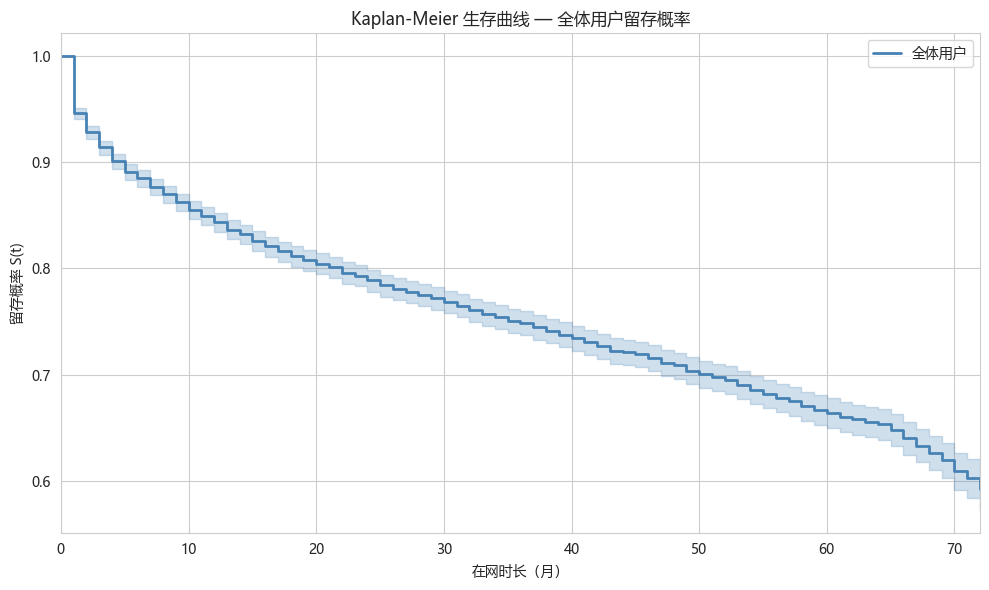

中位生存时间: inf 个月
（超过50%用户在整个观察期内未流失，中位生存时间为无穷大）
12个月留存率: 0.8432
24个月留存率: 0.7887
72个月留存率: 0.5928


In [20]:
kmf = KaplanMeierFitter()
kmf.fit(df['tenure'], df['event'], label='全体用户')

fig, ax = plt.subplots(figsize=(10, 6))
kmf.plot_survival_function(ax=ax, ci_show=True, color='steelblue', linewidth=2)
ax.set_xlabel('在网时长（月）')
ax.set_ylabel('留存概率 S(t)')
ax.set_title('Kaplan-Meier 生存曲线 — 全体用户留存概率')
ax.set_xlim(0, 72)

# 标记中位生存时间
median_t = kmf.median_survival_time_
if median_t != float('inf'):
    ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label=f'中位生存时间 = {median_t:.1f}月')
    ax.axvline(median_t, color='red', linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
safe_savefig('output/10_km_overall.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'中位生存时间: {median_t:.1f} 个月')
if median_t == float('inf'):
    print('（超过50%用户在整个观察期内未流失，中位生存时间为无穷大）')
print(f'12个月留存率: {kmf.survival_function_at_times(12).values[0]:.4f}')
print(f'24个月留存率: {kmf.survival_function_at_times(24).values[0]:.4f}')
print(f'72个月留存率: {kmf.survival_function_at_times(72).values[0]:.4f}')

### 2.2 按合同类型分组的 KM 曲线

从 EDA 我们知道合同类型是流失的强影响因素。现在用生存曲线直观对比。

**Log-rank 检验**：检验两条（或多条）生存曲线是否有显著差异。
- H0: 两组生存曲线没有差异
- p < 0.05 拒绝 H0，说明差异显著

⚠️ 原文件被占用，已保存到: output/11_km_by_contract_new.png


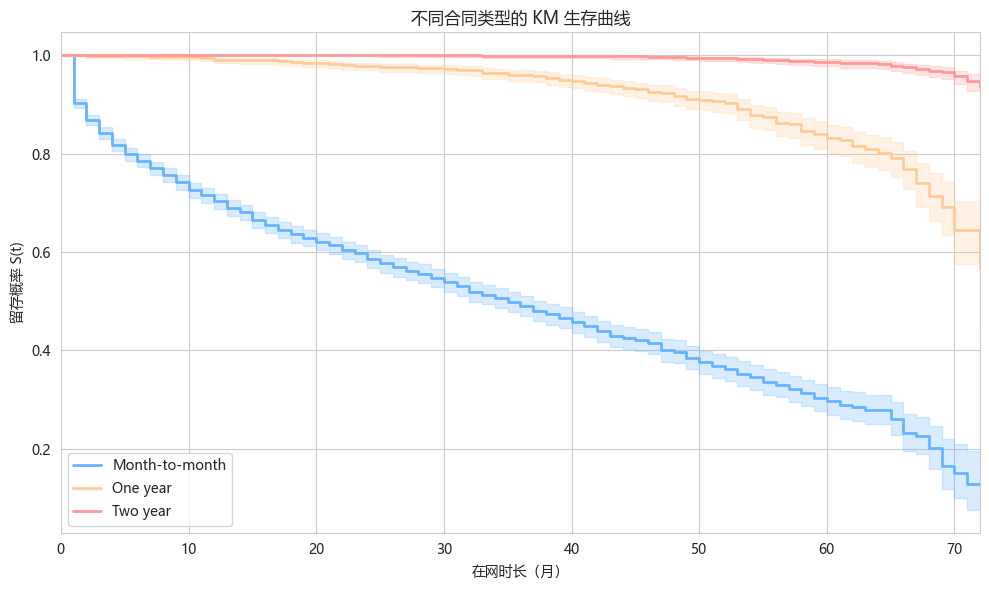

Log-rank 检验结果（三组合同类型）:
  检验统计量 = 2352.87
  p值 = 0.00e+00
  结论: p < 0.05，三组生存曲线有显著差异


In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#66b3ff', '#ffcc99', '#ff9999']

for i, contract in enumerate(['Month-to-month', 'One year', 'Two year']):
    mask = df['Contract'] == contract
    kmf_temp = KaplanMeierFitter()
    kmf_temp.fit(df.loc[mask, 'tenure'], df.loc[mask, 'event'], label=contract)
    kmf_temp.plot_survival_function(ax=ax, ci_show=True, color=colors[i], linewidth=2)

ax.set_xlabel('在网时长（月）')
ax.set_ylabel('留存概率 S(t)')
ax.set_title('不同合同类型的 KM 生存曲线')
ax.set_xlim(0, 72)
plt.tight_layout()
safe_savefig('output/11_km_by_contract.png', dpi=300, bbox_inches='tight')
plt.show()

# Log-rank 检验（三组比较）
results = multivariate_logrank_test(
    df['tenure'], df['Contract'], df['event']
)
print(f'Log-rank 检验结果（三组合同类型）:')
print(f'  检验统计量 = {results.test_statistic:.2f}')
print(f'  p值 = {results.p_value:.2e}')
if results.p_value < 0.05:
    print('  结论: p < 0.05，三组生存曲线有显著差异')
else:
    print('  结论: p >= 0.05，三组生存曲线无显著差异')

# 2.3 按网络服务类型分组的 KM 曲线

⚠️ 原文件被占用，已保存到: output/12_km_by_internet_new.png


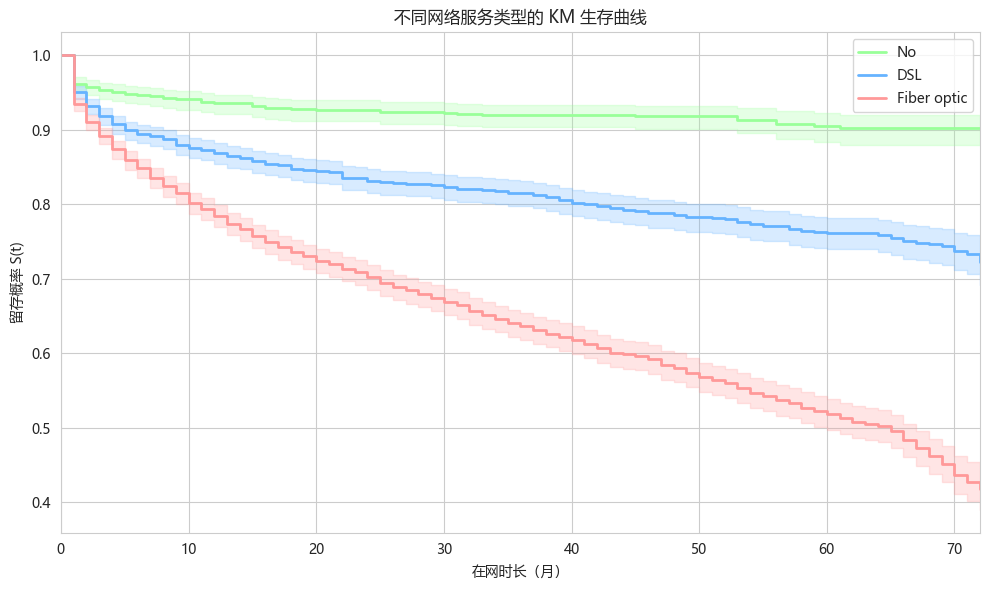

Log-rank 检验结果（三组网络服务）:
  检验统计量 = 520.12
  p值 = 1.14e-113
  结论: p < 0.05，不同网络服务类型的生存曲线有显著差异


In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
colors_is = ['#99ff99', '#66b3ff', '#ff9999']

for i, is_type in enumerate(['No', 'DSL', 'Fiber optic']):
    mask = df['InternetService'] == is_type
    kmf_temp = KaplanMeierFitter()
    kmf_temp.fit(df.loc[mask, 'tenure'], df.loc[mask, 'event'], label=is_type)
    kmf_temp.plot_survival_function(ax=ax, ci_show=True, color=colors_is[i], linewidth=2)

ax.set_xlabel('在网时长（月）')
ax.set_ylabel('留存概率 S(t)')
ax.set_title('不同网络服务类型的 KM 生存曲线')
ax.set_xlim(0, 72)
plt.tight_layout()
safe_savefig('output/12_km_by_internet.png', dpi=300, bbox_inches='tight')
plt.show()

results = multivariate_logrank_test(
    df['tenure'], df['InternetService'], df['event']
)
print(f'Log-rank 检验结果（三组网络服务）:')
print(f'  检验统计量 = {results.test_statistic:.2f}')
print(f'  p值 = {results.p_value:.2e}')
if results.p_value < 0.05:
    print('  结论: p < 0.05，不同网络服务类型的生存曲线有显著差异')
else:
    print('  结论: p >= 0.05，无显著差异')

### 2.4 老年用户 vs 非老年用户

⚠️ 原文件被占用，已保存到: output/13_km_by_senior_new.png


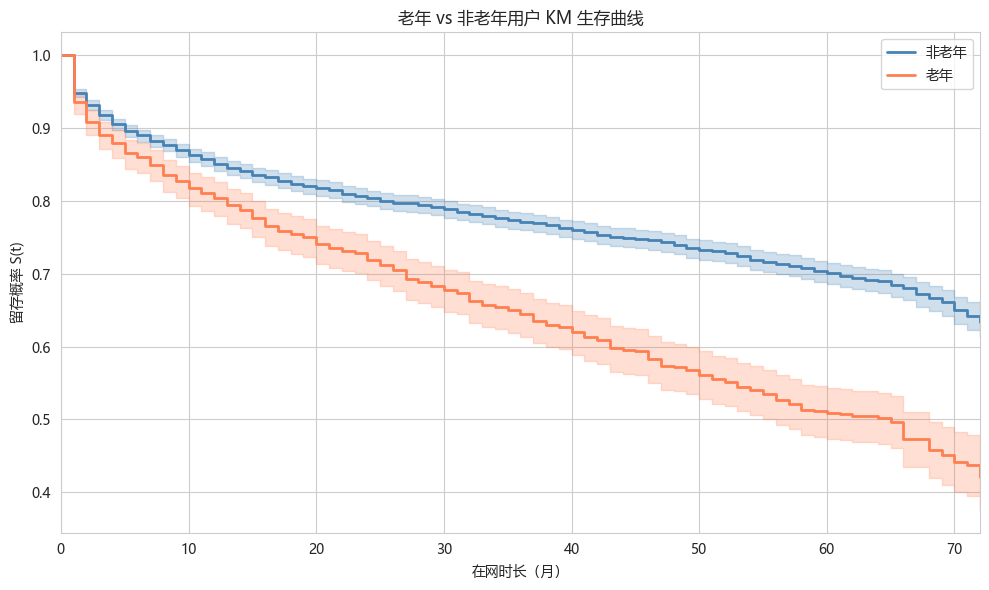

Log-rank 检验结果（老年 vs 非老年）:
  检验统计量 = 109.49
  p值 = 1.27e-25
  结论: p < 0.05，老年与非老年用户的生存曲线有显著差异


In [23]:
fig, ax = plt.subplots(figsize=(10, 6))

for i, (label, mask) in enumerate([('非老年', df['SeniorCitizen'] == 0), ('老年', df['SeniorCitizen'] == 1)]):
    kmf_temp = KaplanMeierFitter()
    kmf_temp.fit(df.loc[mask, 'tenure'], df.loc[mask, 'event'], label=label)
    kmf_temp.plot_survival_function(ax=ax, ci_show=True, color=['steelblue', 'coral'][i], linewidth=2)

ax.set_xlabel('在网时长（月）')
ax.set_ylabel('留存概率 S(t)')
ax.set_title('老年 vs 非老年用户 KM 生存曲线')
ax.set_xlim(0, 72)
plt.tight_layout()
safe_savefig('output/13_km_by_senior.png', dpi=300, bbox_inches='tight')
plt.show()

# 两组 Log-rank 检验
mask_old = df['SeniorCitizen'] == 1
result = logrank_test(
    df.loc[mask_old, 'tenure'], df.loc[~mask_old, 'tenure'],
    df.loc[mask_old, 'event'], df.loc[~mask_old, 'event']
)
print(f'Log-rank 检验结果（老年 vs 非老年）:')
print(f'  检验统计量 = {result.test_statistic:.2f}')
print(f'  p值 = {result.p_value:.2e}')
if result.p_value < 0.05:
    print('  结论: p < 0.05，老年与非老年用户的生存曲线有显著差异')
else:
    print('  结论: p >= 0.05，无显著差异')

### 2.5 有伴侣 vs 无伴侣

⚠️ 原文件被占用，已保存到: output/14_km_by_partner_new.png


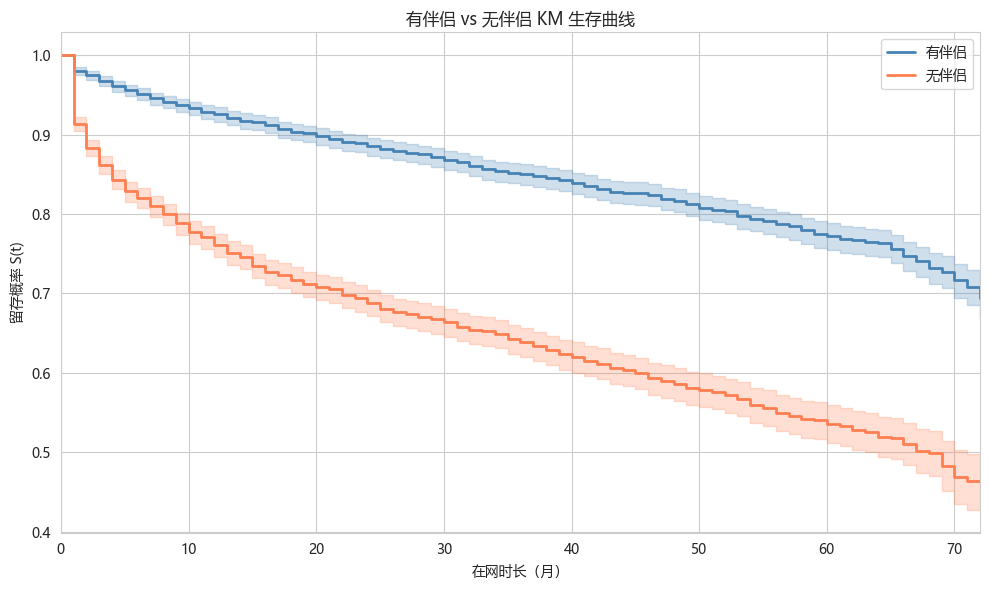

Log-rank 检验结果（有伴侣 vs 无伴侣）:
  检验统计量 = 423.54
  p值 = 4.13e-94
  结论: p < 0.05，有/无伴侣用户的生存曲线有显著差异


In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

for i, (label, mask) in enumerate([('有伴侣', df['Partner'] == 'Yes'), ('无伴侣', df['Partner'] == 'No')]):
    kmf_temp = KaplanMeierFitter()
    kmf_temp.fit(df.loc[mask, 'tenure'], df.loc[mask, 'event'], label=label)
    kmf_temp.plot_survival_function(ax=ax, ci_show=True, color=['steelblue', 'coral'][i], linewidth=2)

ax.set_xlabel('在网时长（月）')
ax.set_ylabel('留存概率 S(t)')
ax.set_title('有伴侣 vs 无伴侣 KM 生存曲线')
ax.set_xlim(0, 72)
plt.tight_layout()
safe_savefig('output/14_km_by_partner.png', dpi=300, bbox_inches='tight')
plt.show()

mask_p = df['Partner'] == 'Yes'
result = logrank_test(
    df.loc[mask_p, 'tenure'], df.loc[~mask_p, 'tenure'],
    df.loc[mask_p, 'event'], df.loc[~mask_p, 'event']
)
print(f'Log-rank 检验结果（有伴侣 vs 无伴侣）:')
print(f'  检验统计量 = {result.test_statistic:.2f}')
print(f'  p值 = {result.p_value:.2e}')
if result.p_value < 0.05:
    print('  结论: p < 0.05，有/无伴侣用户的生存曲线有显著差异')
else:
    print('  结论: p >= 0.05，无显著差异')

### 2.6 按付款方式分组

⚠️ 原文件被占用，已保存到: output/15_km_by_payment_new.png


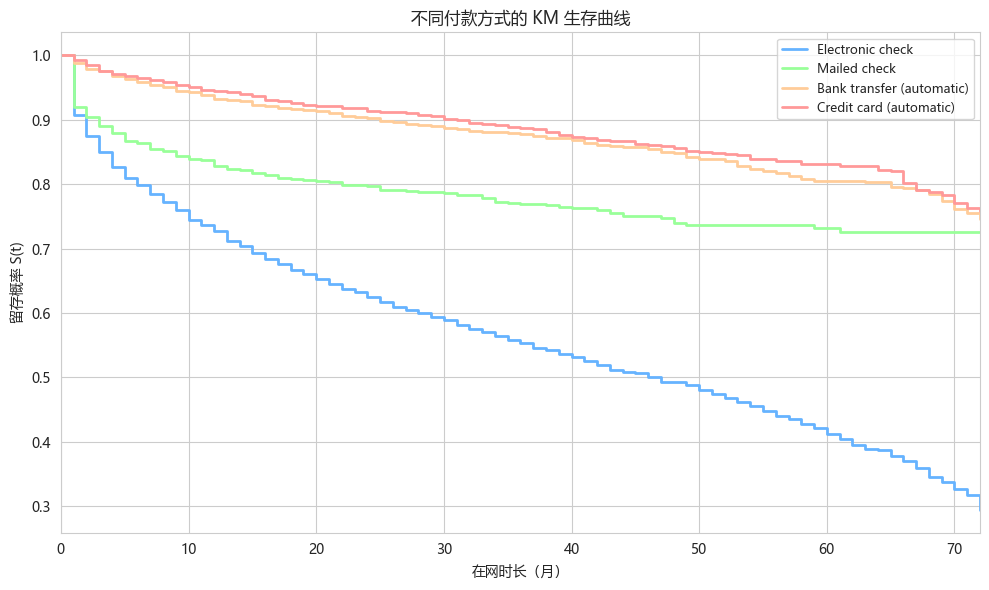

Log-rank 检验结果（四组付款方式）:
  检验统计量 = 865.24
  p值 = 3.07e-187
  结论: p < 0.05，不同付款方式的生存曲线有显著差异


In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
colors_pm = ['#66b3ff', '#99ff99', '#ffcc99', '#ff9999']

for i, pm in enumerate(['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']):
    mask = df['PaymentMethod'] == pm
    kmf_temp = KaplanMeierFitter()
    kmf_temp.fit(df.loc[mask, 'tenure'], df.loc[mask, 'event'], label=pm)
    kmf_temp.plot_survival_function(ax=ax, ci_show=False, color=colors_pm[i], linewidth=2)

ax.set_xlabel('在网时长（月）')
ax.set_ylabel('留存概率 S(t)')
ax.set_title('不同付款方式的 KM 生存曲线')
ax.set_xlim(0, 72)
ax.legend(fontsize=9)
plt.tight_layout()
safe_savefig('output/15_km_by_payment.png', dpi=300, bbox_inches='tight')
plt.show()

results = multivariate_logrank_test(
    df['tenure'], df['PaymentMethod'], df['event']
)
print(f'Log-rank 检验结果（四组付款方式）:')
print(f'  检验统计量 = {results.test_statistic:.2f}')
print(f'  p值 = {results.p_value:.2e}')
if results.p_value < 0.05:
    print('  结论: p < 0.05，不同付款方式的生存曲线有显著差异')
else:
    print('  结论: p >= 0.05，无显著差异')

## 3. 生存概率汇总表

汇总各群体在关键时间点（12月、24月、36月）的留存概率，方便对比。

In [26]:
def survival_at_times(group_col, group_val, times=[12, 24, 36, 48]):
    """计算某群体在指定时间点的留存概率"""
    mask = df[group_col] == group_val
    kmf_temp = KaplanMeierFitter()
    kmf_temp.fit(df.loc[mask, 'tenure'], df.loc[mask, 'event'])
    result = {}
    for t in times:
        val = kmf_temp.survival_function_at_times(t).values
        result[f'{t}月'] = f'{val[0]:.1%}' if len(val) > 0 else 'N/A'
    return result

# 合同类型
print('=== 各合同类型留存概率 ===')
for c in ['Month-to-month', 'One year', 'Two year']:
    print(f'  {c}: {survival_at_times("Contract", c)}')

# 网络服务
print('=== 各网络服务留存概率 ===')
for s in ['No', 'DSL', 'Fiber optic']:
    print(f'  {s}: {survival_at_times("InternetService", s)}')

# 老年 vs 非老年
print('=== 老年/非老年留存概率 ===')
print(f'  非老年: {survival_at_times("SeniorCitizen", 0)}')
print(f'  老年: {survival_at_times("SeniorCitizen", 1)}')

=== 各合同类型留存概率 ===
  Month-to-month: {'12月': '70.3%', '24月': '58.6%', '36月': '49.1%', '48月': '39.7%'}
  One year: {'12月': '99.1%', '24月': '97.8%', '36月': '95.9%', '48月': '91.7%'}
  Two year: {'12月': '100.0%', '24月': '100.0%', '36月': '99.9%', '48月': '99.6%'}
=== 各网络服务留存概率 ===
  No: {'12月': '93.5%', '24月': '92.6%', '36月': '92.0%', '48月': '91.8%'}
  DSL: {'12月': '86.8%', '24月': '83.1%', '36月': '81.5%', '48月': '78.5%'}
  Fiber optic: {'12月': '78.4%', '24月': '70.2%', '36月': '63.6%', '48月': '58.1%'}
=== 老年/非老年留存概率 ===
  非老年: {'12月': '85.1%', '24月': '80.3%', '36月': '77.1%', '48月': '74.0%'}
  老年: {'12月': '80.4%', '24月': '71.9%', '36月': '64.4%', '48月': '57.2%'}


## 4. 关键发现总结

1. **总体留存**：12个月留存率约 XX%，72个月留存率约 XX%
2. **合同类型**：按月签约下降最快，两年合同最平缓，Log-rank p<0.001
3. **网络服务**：光纤用户生存曲线明显低于DSL和无网络用户
4. **老年用户**：老年用户流失风险显著高于非老年
5. **伴侣**：无伴侣用户流失风险更高
6. **付款方式**：电子支票用户生存曲线最低

用 KM 估计了用户留存函数，Log-rank 检验验证了 6 组群体的流失差异。
合同类型差异最大，按月签约用户留存率远低于长期合同用户。

## 5. 保存数据

In [28]:
df.to_csv('data/telco_churn_survival.csv', index=False)
print('✅ 生存分析数据已保存到 data/telco_churn_survival.csv')
print(f'   包含 {len(df)} 条记录，event 列: 1=流失, 0=删失')

PermissionError: [Errno 13] Permission denied: 'data/telco_churn_survival.csv'